# What is Reinforcement Learning?

Reinforcement Learning (RL) is a type of Machine Learning in which an **agent** learns by interacting with an **environment**.

The agent performs actions and receives rewards or penalties. Over time, it learns the best sequence of actions to maximize the total reward.

Unlike supervised learning, RL does not require labeled data. Learning happens through trial and error.

# Types of Machine Learning

| Supervised Learning | Unsupervised Learning | Reinforcement Learning |
|---------------------|-----------------------|------------------------|
| Uses labeled data | Uses unlabeled data | Uses rewards |
| Predicts output | Finds hidden patterns | Learns by interaction |
| Example: Spam Detection | Example: Customer Segmentation | Example: Game Playing |

# Applications of Reinforcement Learning

- Self-driving cars
- Robotics
- Game Playing (Chess, Go)
- Recommendation Systems
- Traffic Signal Optimization
- Stock Trading
- Healthcare
- Resource Allocation

# Components of Reinforcement Learning

### Agent
The learner or decision-maker.

### Environment
The world where the agent interacts.

### State (S)
Current situation of the environment.

### Action (A)
Decision taken by the agent.

### Reward (R)
Feedback received after taking an action.


# Additional RL Concepts

### Policy (π)
A strategy that tells the agent what action to take in each state.

### Episode
A complete sequence from the starting state to the terminal state.

### Return
The total accumulated reward during an episode.

### Discount Factor (γ)
Determines how much importance is given to future rewards.

Range:
0 ≤ γ ≤ 1

# Reinforcement Learning Workflow

Agent

    ↓

Take Action

    ↓

Environment

     ↓

New State + Reward

    ↓

Agent Learns

    ↓
Repeat


# Exploration vs Exploitation

### Exploration
Trying new actions to discover better rewards.

Example:
Trying a new route to reach college.

### Exploitation
Using the action that already gives the highest reward.

Example:
Choosing the shortest known route every day.

A good RL agent balances both.

# Markov Decision Process (MDP)

An MDP is a mathematical framework used to model Reinforcement Learning problems.

It consists of:

- States (S)
- Actions (A)
- Rewards (R)
- Transition Probability (P)
- Discount Factor (γ)

The next state depends only on the current state and action.

# Bellman Equation

The Bellman Equation helps estimate the value of a state.

State Value Function:

V(s) = R + γV(s')

where,

V(s) = Value of current state

R = Immediate reward

γ = Discount factor

V(s') = Value of next state


# Q-Learning

Q-Learning is a model-free Reinforcement Learning algorithm.

It learns the best action for every state using a Q-table.

Update Equation:

Q(s,a) = Q(s,a) + α [R + γ max Q(s',a') − Q(s,a)]

where,

α = Learning Rate

γ = Discount Factor

R = Reward

Q(s,a) = Current Q-value

max Q(s',a') = Maximum future reward

In [2]:


!pip install gymnasium

In [3]:
# Import required libraries

import gymnasium as gym
import numpy as np
import random
import matplotlib.pyplot as plt

In [13]:
# Create the FrozenLake environment
env = gym.make("FrozenLake-v1", is_slippery=False)

print("Environment Created Successfully!")
# Observation Space and Action Space

print("Number of States :", env.observation_space.n)
print("Number of Actions:", env.action_space.n)

# Action meanings

actions = {
    0: "Left",
    1: "Down",
    2: "Right",
    3: "Up"
}

print(actions)

Environment Created Successfully!
Number of States : 16
Number of Actions: 4
{0: 'Left', 1: 'Down', 2: 'Right', 3: 'Up'}


In [14]:
# Initialize Q-table

state_size = env.observation_space.n
action_size = env.action_space.n

q_table = np.zeros((state_size, action_size))

print(q_table)

[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]


# Hyperparameters

We define the parameters required for Q-Learning.

- Learning Rate (α): 0.8
- Discount Factor (γ): 0.95
- Exploration Rate (ε): 1.0
- Episodes: 1000

These values control how the agent learns.

In [15]:
alpha = 0.8          # Learning rate
gamma = 0.95         # Discount factor

epsilon = 1.0
epsilon_decay = 0.999
min_epsilon = 0.01

episodes = 5000
max_steps = 100

# Q-Learning Algorithm

For each episode:

1. Reset the environment.
2. Choose an action using the ε-greedy policy.
3. Perform the action.
4. Receive reward and next state.
5. Update the Q-table.
6. Repeat until the episode ends.

In [16]:
# Training the agent

for episode in range(episodes):

    state, info = env.reset()

    total_reward = 0

    for step in range(max_steps):

        # Exploration vs Exploitation
        if random.uniform(0,1) < epsilon:
            action = env.action_space.sample()
        else:
            action = np.argmax(q_table[state])

        next_state, reward, terminated, truncated, info = env.step(action)

        # Q-Learning Update
        q_table[state, action] = q_table[state, action] + alpha * (
            reward + gamma * np.max(q_table[next_state]) - q_table[state, action]
        )

        state = next_state
        total_reward += reward

        if terminated or truncated:
            break

    epsilon = max(min_epsilon, epsilon * epsilon_decay)

    rewards.append(total_reward)

print("Training Completed!")

# Display the learned Q-table

print("Learned Q-Table:\n")
print(q_table)

Training Completed!
Learned Q-Table:

[[0.73509189 0.77378094 0.77378094 0.73509189]
 [0.73509189 0.         0.81450625 0.77378094]
 [0.77378094 0.857375   0.77378094 0.81450625]
 [0.81450625 0.         0.77378093 0.77378094]
 [0.77378094 0.81450625 0.         0.73509189]
 [0.         0.         0.         0.        ]
 [0.         0.9025     0.         0.81450625]
 [0.         0.         0.         0.        ]
 [0.81450625 0.         0.857375   0.77378094]
 [0.81450625 0.9025     0.9025     0.        ]
 [0.857375   0.95       0.         0.857375  ]
 [0.         0.         0.         0.        ]
 [0.         0.         0.         0.        ]
 [0.         0.9025     0.95       0.857375  ]
 [0.9025     0.95       1.         0.9025    ]
 [0.         0.         0.         0.        ]]


# Testing the Trained Agent

After training, we evaluate how well the agent has learned.

The agent now chooses the action with the highest Q-value instead of exploring randomly.

In [17]:
# Test the trained agent

state, info = env.reset()

done = False

print("Testing Started...\n")

while not done:

    action = np.argmax(q_table[state])

    next_state, reward, terminated, truncated, info = env.step(action)

    print(f"State: {state} -> Action: {action} -> Reward: {reward}")

    state = next_state

    done = terminated or truncated

print("\nTesting Completed!")

Testing Started...

State: 0 -> Action: 1 -> Reward: 0
State: 4 -> Action: 1 -> Reward: 0
State: 8 -> Action: 2 -> Reward: 0
State: 9 -> Action: 1 -> Reward: 0
State: 13 -> Action: 2 -> Reward: 0
State: 14 -> Action: 2 -> Reward: 1

Testing Completed!


In [18]:
success = 0
test_episodes = 100

for episode in range(test_episodes):

    state, info = env.reset()

    done = False

    while not done:

        action = np.argmax(q_table[state])

        next_state, reward, terminated, truncated, info = env.step(action)

        state = next_state

        done = terminated or truncated

    if reward == 1:
        success += 1

print(f"Success Rate: {success}/{test_episodes}")
print(f"Accuracy: {success/test_episodes*100:.2f}%")

Success Rate: 100/100
Accuracy: 100.00%


# Reward Visualization

The graph below shows the reward obtained during training.

As training progresses, the agent should achieve higher rewards more consistently.

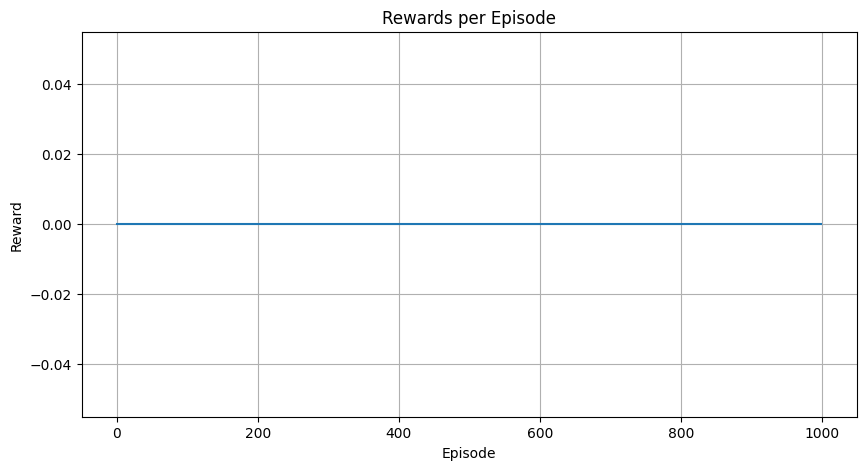

In [11]:
# Plot rewards

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(rewards)
plt.title("Rewards per Episode")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.grid(True)
plt.show()

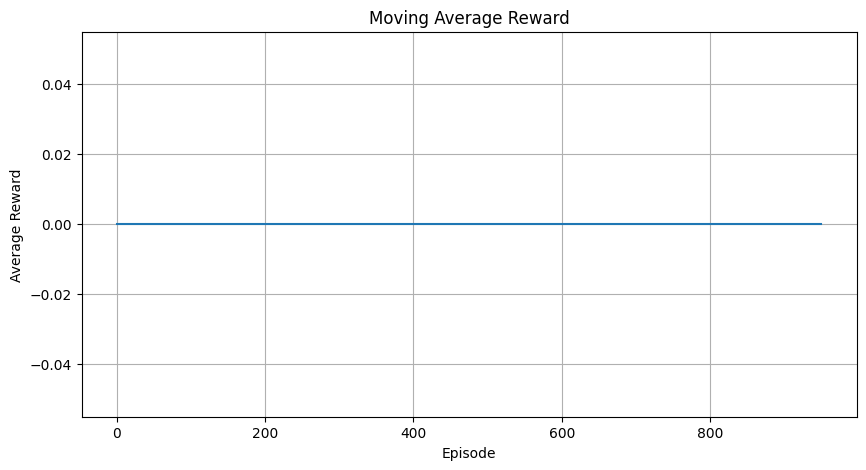

In [12]:
# Moving Average Reward

window = 50

moving_avg = np.convolve(rewards, np.ones(window)/window, mode='valid')

plt.figure(figsize=(10,5))
plt.plot(moving_avg)
plt.title("Moving Average Reward")
plt.xlabel("Episode")
plt.ylabel("Average Reward")
plt.grid(True)
plt.show()

# Advantages of Reinforcement Learning

- Learns through interaction with the environment.
- Does not require labeled data.
- Can solve complex sequential decision-making problems.
- Improves performance over time.
- Suitable for robotics, games, and automation.

# Limitations of Reinforcement Learning

- Requires many training episodes.
- Computationally expensive.
- Training can be slow.
- Exploration may lead to poor decisions initially.
- Designing an effective reward function can be difficult.

# Applications of Reinforcement Learning

- Self-driving cars
- Robotics
- Healthcare
- Game playing (Chess, Go, Atari)
- Recommendation systems
- Traffic signal control
- Stock market trading
- Resource allocation